Train size : 248  (83 terminated)
Test size  : 63  (21 terminated)

── Cross-validation (5-fold) ──────────────────────────────
  Accuracy : 0.624 ± 0.057
  F1       : 0.518 ± 0.067

── Test set results ───────────────────────────────────────
                precision    recall  f1-score   support

    Active (0)       0.83      0.69      0.75        42
Terminated (1)       0.54      0.71      0.61        21

      accuracy                           0.70        63
     macro avg       0.68      0.70      0.68        63
  weighted avg       0.73      0.70      0.71        63



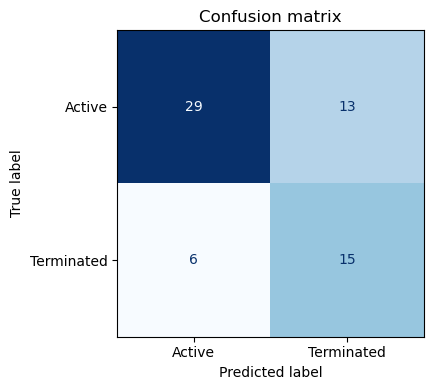

Plot saved → baseline_results.png

── Top 10 most influential features ──────────────────────
RaceDesc_White                         0.564308
RecruitmentSource_Website             -0.537887
RecruitmentSource_Employee Referral   -0.531679
RecruitmentSource_LinkedIn            -0.500757
RecruitmentSource_Indeed              -0.482692
RaceDesc_Black or African American     0.455850
DaysLateLast30                         0.395057
RecruitmentSource_Other               -0.366884
ManagerID                              0.338600
MarriedID                              0.327984


In [74]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# ── Load cleaned data ─────────────────────────────────────────────────────────
df = pd.read_csv("hr_cleaned.csv")
X = df.drop(columns=["Termd"])
y = df["Termd"]

# ── Train / Test split (stratified to preserve 2:1 ratio) ────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size : {X_train.shape[0]}  ({y_train.sum()} terminated)")
print(f"Test size  : {X_test.shape[0]}  ({y_test.sum()} terminated)\n")

# ── Pipeline: scale → logistic regression ────────────────────────────────────
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

# ── Cross-validation (5-fold stratified) ─────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_validate(
    pipeline, X_train, y_train, cv=cv,
    scoring=["accuracy", "f1"],
    return_train_score=False
)

print("── Cross-validation (5-fold) ──────────────────────────────")
print(f"  Accuracy : {cv_results['test_accuracy'].mean():.3f} ± {cv_results['test_accuracy'].std():.3f}")
print(f"  F1       : {cv_results['test_f1'].mean():.3f} ± {cv_results['test_f1'].std():.3f}\n")

# ── Final fit on full train set → evaluate on test set ───────────────────────
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print("── Test set results ───────────────────────────────────────")
print(classification_report(y_test, y_pred, target_names=["Active (0)", "Terminated (1)"]))

# ── confusion matrix ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=["Active", "Terminated"]
).plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion matrix")
plt.tight_layout()
plt.savefig("baseline_results.png", dpi=150)
plt.show()
print("Plot saved → baseline_results.png")

# ── Top feature coefficients avec coef_ ──────────────────────────────────────────────────
coefs = pd.Series(
    pipeline.named_steps["clf"].coef_[0],
    index=X.columns
).sort_values(key=abs, ascending=False)

print("\n── Top 10 most influential features ──────────────────────")
print(coefs.head(10).to_string())

scale_pos_weight = 1.99  (165 active / 83 terminated)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


C:\Users\othma\miniconda3\envs\torch311\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
C:\Users\othma\miniconda3\envs\torch311\Lib\site-packages\xgboost\training.py:200: UserWarning: [14:43:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Best params : {'subsample': 0.6, 'n_estimators': 400, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.6}
Best CV AUC : 0.663

── Test set results ───────────────────────────────────────
                precision    recall  f1-score   support

    Active (0)       0.74      0.83      0.79        42
Terminated (1)       0.56      0.43      0.49        21

      accuracy                           0.70        63
     macro avg       0.65      0.63      0.64        63
  weighted avg       0.68      0.70      0.69        63

  ROC-AUC : 0.678

  Train AUC : 1.000
  Test  AUC : 0.678
  Gap       : 0.322  possible overfit



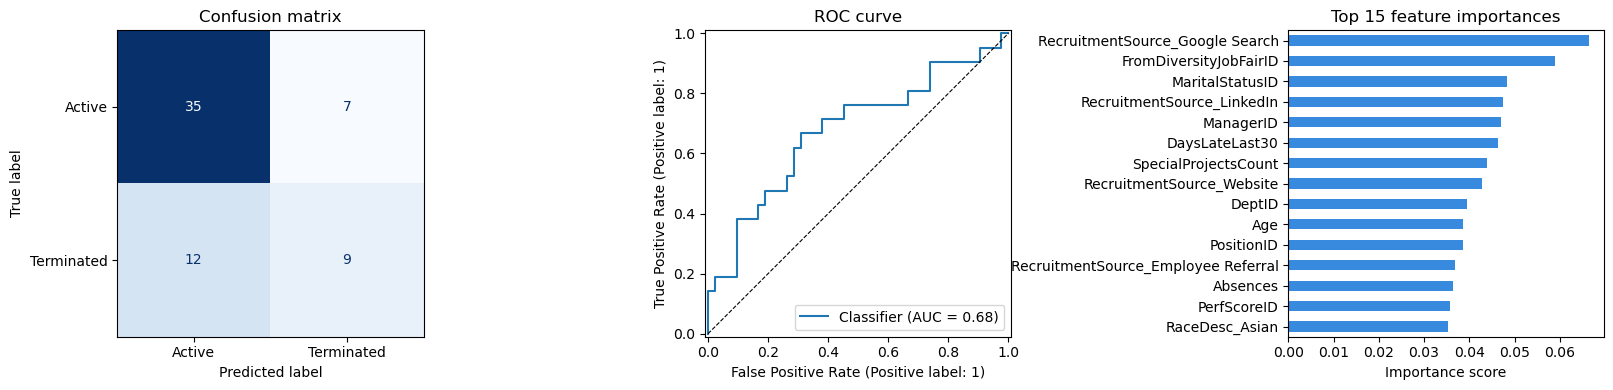

Plot saved → xgboost_results.png


In [73]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, RocCurveDisplay, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

# ── Load ──────────────────────────────────────────────────────────────────────
df = pd.read_csv("hr_cleaned.csv")



X = df.drop(columns=["Termd"])
y = df["Termd"]

# ── Train / Test split ────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── Class imbalance ratio for scale_pos_weight ───────────────────────────────
# XGBoost handles imbalance via scale_pos_weight = count(0) / count(1)
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale = neg / pos
print(f"scale_pos_weight = {scale:.2f}  ({neg} active / {pos} terminated)\n")

# ── Hyperparameter search ─────────────────────────────────────────────────────
param_grid = {
    "n_estimators":      [100, 200, 300, 400],
    "max_depth":         [2, 3, 4, 5],
    "learning_rate":     [0.01, 0.05, 0.1, 0.2],
    "subsample":         [0.6, 0.8, 1.0],
    "colsample_bytree":  [0.6, 0.8, 1.0],
    "min_child_weight":  [1, 3, 5],
    "gamma":             [0, 0.1, 0.3],
}

xgb = XGBClassifier(
    scale_pos_weight=scale,
    eval_metric="auc",
    random_state=42,
    use_label_encoder=False
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    xgb,
    param_distributions=param_grid,
    n_iter=50,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

print(f"\nBest params : {search.best_params_}")
print(f"Best CV AUC : {search.best_score_:.3f}\n")

# ── Evaluate best model on test set ──────────────────────────────────────────
best_model = search.best_estimator_
y_pred  = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("── Test set results ───────────────────────────────────────")
print(classification_report(y_test, y_pred, target_names=["Active (0)", "Terminated (1)"]))
print(f"  ROC-AUC : {roc_auc_score(y_test, y_proba):.3f}\n")

# ── Train vs Test AUC gap ─────────────────────────────────────────────────────
train_auc = roc_auc_score(y_train, best_model.predict_proba(X_train)[:, 1])
test_auc  = roc_auc_score(y_test, y_proba)
print(f"  Train AUC : {train_auc:.3f}")
print(f"  Test  AUC : {test_auc:.3f}")
print(f"  Gap       : {train_auc - test_auc:.3f}  {'possible overfit' if train_auc - test_auc > 0.05 else ' gap is small'}\n")

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=["Active", "Terminated"]
).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion matrix")

# ROC curve
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].plot([0, 1], [0, 1], "k--", linewidth=0.8)
axes[1].set_title("ROC curve")

# Feature importance avec coef_
importance = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=True).tail(15)

importance.plot(kind="barh", ax=axes[2], color="#378ADD")
axes[2].set_title("Top 15 feature importances")
axes[2].set_xlabel("Importance score")

plt.tight_layout()
plt.savefig("xgboost_results.png", dpi=150)
plt.show()
print("Plot saved → xgboost_results.png")

Train size : 248  (83 terminated)
Test size  : 63  (21 terminated)

── Test set results ───────────────────────────────────────
                precision    recall  f1-score   support

    Active (0)       0.77      0.86      0.81        42
Terminated (1)       0.62      0.48      0.54        21

      accuracy                           0.73        63
     macro avg       0.70      0.67      0.67        63
  weighted avg       0.72      0.73      0.72        63

  ROC-AUC : 0.785

  Train AUC : 0.892
  Test  AUC : 0.785
  Gap       : 0.108   possible overfit



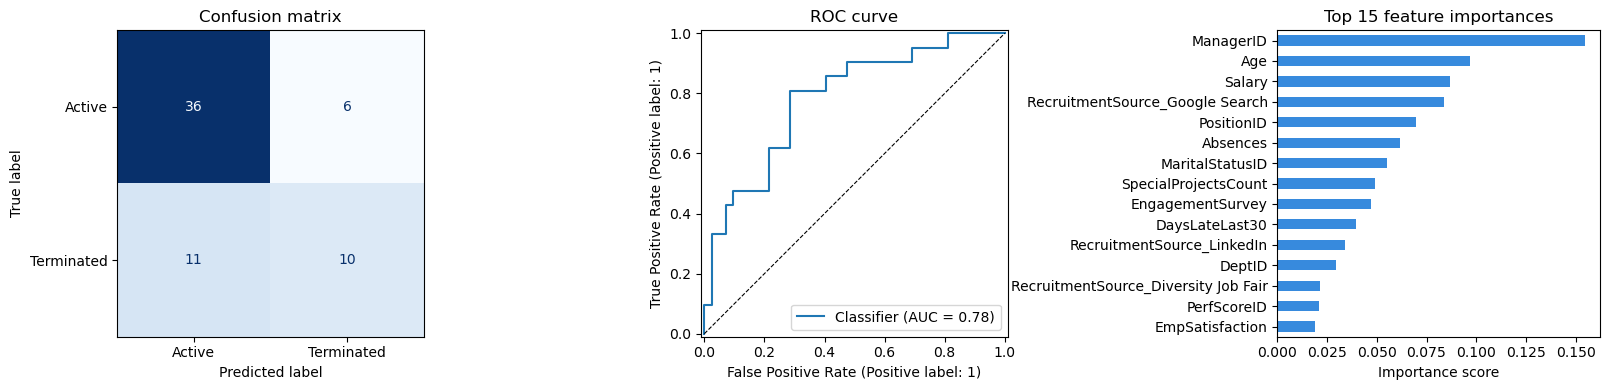

In [78]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, RocCurveDisplay, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# ── Load ──────────────────────────────────────────────────────────────────────
df = pd.read_csv("hr_cleaned.csv")

X = df.drop(columns=["Termd"])
y = df["Termd"]

# ── Train / Test split ────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size : {X_train.shape[0]}  ({y_train.sum()} terminated)")
print(f"Test size  : {X_test.shape[0]}  ({y_test.sum()} terminated)\n")

# ── Model ─────────────────────────────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=4,
    min_samples_leaf=5,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42
)

# ── Cross-validation ──────────────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_validate(
    rf, X_train, y_train, cv=cv,
    scoring=["accuracy", "f1", "roc_auc"],
    return_train_score=False
)

# ── Final fit → test set ──────────────────────────────────────────────────────
rf.fit(X_train, y_train)
y_pred  = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

print("── Test set results ───────────────────────────────────────")
print(classification_report(y_test, y_pred, target_names=["Active (0)", "Terminated (1)"]))
print(f"  ROC-AUC : {roc_auc_score(y_test, y_proba):.3f}")

# ── Overfit check ─────────────────────────────────────────────────────────────
train_auc = roc_auc_score(y_train, rf.predict_proba(X_train)[:, 1])
test_auc  = roc_auc_score(y_test, y_proba)
print(f"\n  Train AUC : {train_auc:.3f}")
print(f"  Test  AUC : {test_auc:.3f}")
print(f"  Gap       : {train_auc - test_auc:.3f}  {' possible overfit' if train_auc - test_auc > 0.05 else ' gap is small'}\n")

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=["Active", "Terminated"]
).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion matrix")

# ROC curve
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].plot([0, 1], [0, 1], "k--", linewidth=0.8)
axes[1].set_title("ROC curve")

# Feature importances en uutilisant le coef
importance = pd.Series(
    rf.feature_importances_, index=X.columns
).sort_values(ascending=True).tail(15)

importance.plot(kind="barh", ax=axes[2], color="#378ADD")
axes[2].set_title("Top 15 feature importances")
axes[2].set_xlabel("Importance score")

plt.tight_layout()
plt.savefig("rf_results.png", dpi=150)
plt.show()
